# OpenCV Image Processing

Stage 1 of the [computer-vision path](../README.md). It builds on [opencv_fundamentals.ipynb](opencv_fundamentals.ipynb): now we change pixel values on purpose, to reduce noise and to find edges and shapes.

## Filtering and Convolution

Image filtering applies a **kernel** (small matrix) to each pixel and its neighbors.

A classical image filter and a convolutional layer both slide a small matrix across the image and combine nearby pixels. The difference is where the kernel comes from.

- In **OpenCV filtering**, we choose the kernel ourselves because we want a specific effect such as blur, sharpening, or edge detection.
- In a **CNN**, the network learns the kernel values automatically from labeled data.

So the operation is closely related, but the learning setup is different: fixed filters are hand-designed tools, while CNN filters are trainable features.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Detailed, noisy images compress poorly as PNG: 80 dpi keeps this notebook small enough to version
plt.rcParams['figure.dpi'] = 80

sample_path = "../resources/images/lenna.png"

img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

### Blurring Filters

Blurring reduces noise and fine detail by replacing each pixel with a combination of its neighbours. The **kernel size** controls the strength. Gaussian and median filters require an odd size (3, 5, 7…), so there is a well-defined centre pixel; the plain average (`cv2.blur`) accepts any size, but odd sizes keep the result centred.

To see what each filter does, we first add two kinds of noise to the image: fine Gaussian grain, and isolated black and white dots (*salt-and-pepper* noise).

| Filter | Key idea | Best use |
|--------|----------|---------|
| **Average** | Plain mean of all neighbours | Fast, general purpose |
| **Gaussian** | Weighted mean — centre pixel counts more | Best general-purpose noise reduction |
| **Median** | Median value of neighbours (not mean) | Removes salt-and-pepper noise without blurring edges |
| **Bilateral** | Gaussian, but ignores pixels with very different brightness | Denoising **while keeping edges sharp** |

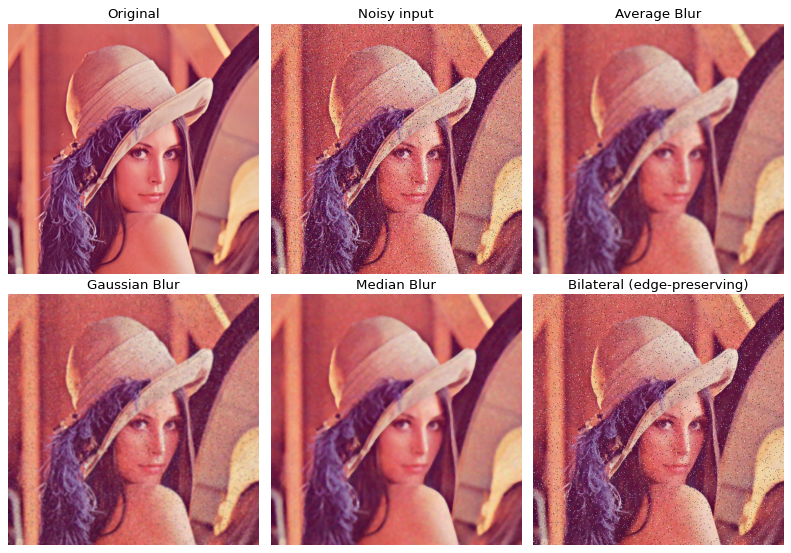

In [ ]:
rng = np.random.default_rng(0)
noisy = np.clip(img_rgb + rng.normal(0, 20, img_rgb.shape), 0, 255).astype(np.uint8)  # Gaussian grain, std 20
dots = rng.random(img_rgb.shape[:2])
noisy[dots < 0.02] = 0     # 2 % black dots
noisy[dots > 0.98] = 255   # 2 % white dots

# (7, 7) kernel: larger = stronger blur.
blur_avg = cv2.blur(noisy, (7, 7))

# sigmaX=0: OpenCV infers the spread from the kernel size automatically.
blur_gauss = cv2.GaussianBlur(noisy, (7, 7), 0)

# Takes a single odd int, not a tuple — unlike the other blur functions.
blur_median = cv2.medianBlur(noisy, 7)

# d=9 (neighbourhood diameter), sigmaColor=75 (colour tolerance), sigmaSpace=75 (spatial spread).
blur_bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes[0, 0].imshow(img_rgb);        axes[0, 0].set_title('Original')
axes[0, 1].imshow(noisy);          axes[0, 1].set_title('Noisy input')
axes[0, 2].imshow(blur_avg);       axes[0, 2].set_title('Average Blur')
axes[1, 0].imshow(blur_gauss);     axes[1, 0].set_title('Gaussian Blur')
axes[1, 1].imshow(blur_median);    axes[1, 1].set_title('Median Blur')
axes[1, 2].imshow(blur_bilateral); axes[1, 2].set_title('Bilateral (edge-preserving)')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

Look at the dots. The average and Gaussian blurs only smear them into grey spots, because one extreme value still pulls the mean. The median removes them: a few extreme values cannot move a median. The bilateral filter smooths the fine grain while keeping edges sharp, but leaves the dots, because to it an isolated extreme pixel looks like an edge worth preserving.

### Custom Kernels

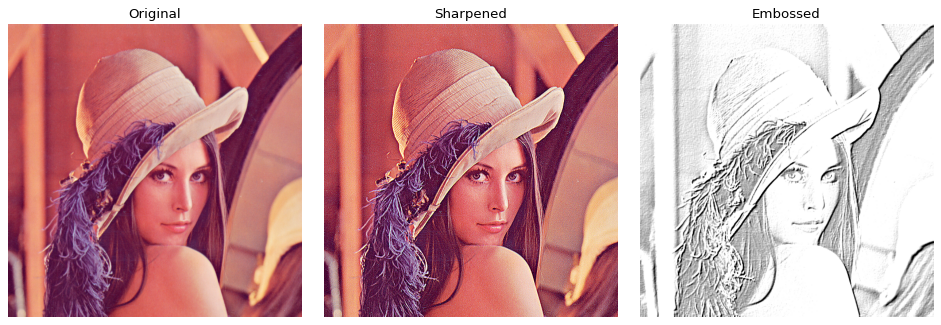

In [ ]:
# Define custom kernels
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

kernel_emboss = np.array([[-2, -1,  0],
                          [-1,  1,  1],
                          [ 0,  1,  2]])

sharpened = cv2.filter2D(img_rgb, -1, kernel_sharpen)

# The emboss kernel produces negative values. Computing in 16-bit and adding 128 maps
# "no change" to mid-grey; with uint8 output every negative value would be clipped to black.
embossed = cv2.filter2D(gray, cv2.CV_16S, kernel_emboss)
embossed = np.clip(embossed.astype(np.int32) + 128, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[1].imshow(sharpened)
axes[1].set_title('Sharpened')
axes[2].imshow(embossed, cmap='gray')
axes[2].set_title('Embossed')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Edge Detection

An **edge** is a place where pixel brightness changes sharply — typically the boundary between two regions or objects. Detecting edges is one of the most fundamental steps in understanding image structure.

Three common detectors, from simplest to most robust:

| Detector | Approach | When to use |
|----------|----------|-------------|
| **Sobel** | Gradient in X or Y direction separately | When you need to know the *direction* of edges |
| **Canny** | Smooth → gradient → hysteresis thresholds | General purpose — the standard choice |
| **Laplacian** | Second derivative in all directions at once | Rarely used alone; very sensitive to noise |

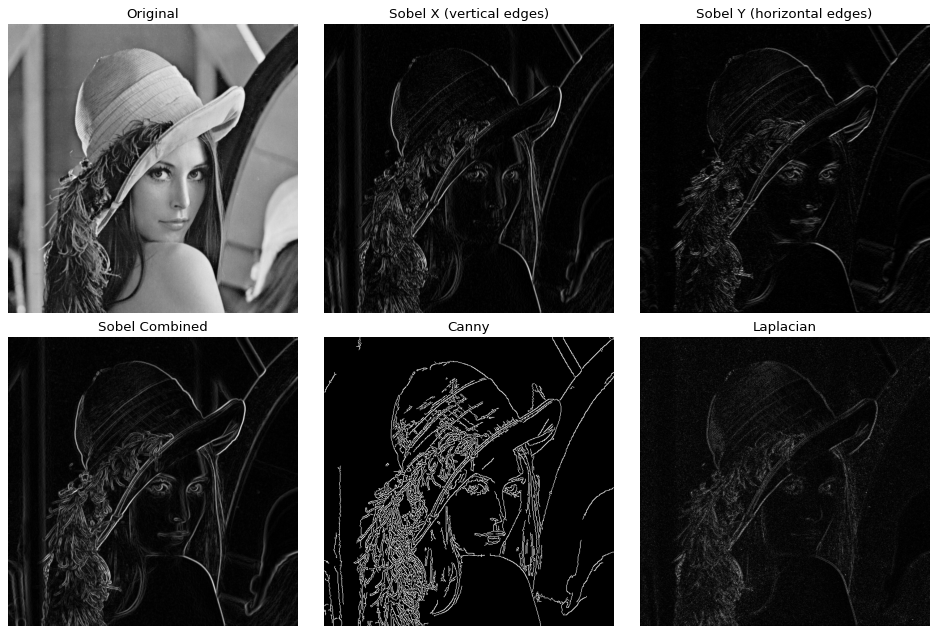

In [ ]:
# CV_64F keeps negative values (edges can point in both directions); use abs() before display.
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  # dx=1, dy=0 → detects vertical edges
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)  # dx=0, dy=1 → detects horizontal edges
sobel_combined = cv2.magnitude(sobel_x, sobel_y)        # overall edge strength in all directions

# Hysteresis thresholds: > 150 → always an edge; < 50 → discarded; in-between → kept only
# if connected to a strong edge. Rule of thumb: upper ≈ 2–3× lower.
canny = cv2.Canny(gray, 50, 150)

# Second-order derivative — very noise-sensitive; pre-blur the image before using in practice.
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(gray, cmap='gray');              axes[0, 0].set_title('Original')
axes[0, 1].imshow(np.abs(sobel_x), cmap='gray');   axes[0, 1].set_title('Sobel X (vertical edges)')
axes[0, 2].imshow(np.abs(sobel_y), cmap='gray');   axes[0, 2].set_title('Sobel Y (horizontal edges)')
axes[1, 0].imshow(sobel_combined, cmap='gray');    axes[1, 0].set_title('Sobel Combined')
axes[1, 1].imshow(canny, cmap='gray');             axes[1, 1].set_title('Canny')
axes[1, 2].imshow(np.abs(laplacian), cmap='gray'); axes[1, 2].set_title('Laplacian')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()


The Laplacian has a second life as a **sharpness measure**: a sharp image has many strong edges, so the *variance* of its Laplacian is high, while a blurred one scores low. The application in [4-face-auth-app](../4-face-auth-app/) uses exactly this to reject blurred photos, and its README shows the limit of the idea: a sharp portrait on a plain background also scores low, simply because it has few edges.

## Thresholding

Thresholding converts a grayscale image into a **binary** (black-and-white) image. Each pixel is compared to a cutoff value: above → white (255), below → black (0).

The challenge is choosing the right cutoff. Three strategies:

| Method | How the threshold is found | Best for |
|--------|-----------------------------|---------|
| **Fixed** | You specify it manually (e.g. 127) | Controlled, uniform lighting |
| **Otsu** | Computed automatically from the image histogram | Images with a clear foreground/background separation |
| **Adaptive** | Computed *per region* of the image | Uneven lighting, shadows, scanned documents |

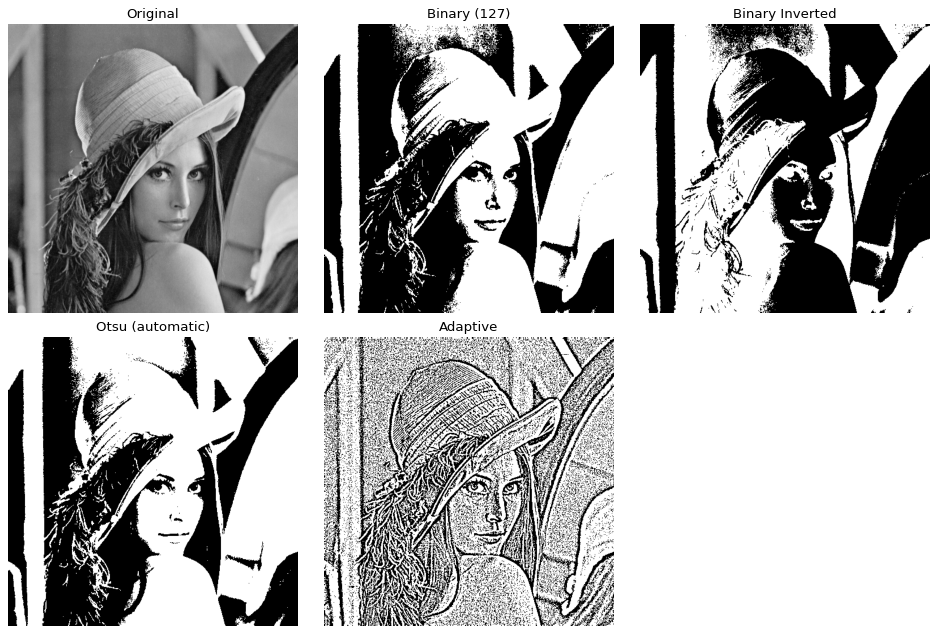

In [ ]:
# Fixed threshold: pixel > 127 → 255, otherwise → 0.
_, thresh_binary     = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
_, thresh_binary_inv = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Otsu: pass threshold=0 — the value is ignored; Otsu computes it automatically.
thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Adaptive: blockSize=11 (local region size, must be odd), C=2 (subtracted from the local mean).
thresh_adaptive = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(gray, cmap='gray');            axes[0, 0].set_title('Original')
axes[0, 1].imshow(thresh_binary, cmap='gray');   axes[0, 1].set_title('Binary (127)')
axes[0, 2].imshow(thresh_binary_inv, cmap='gray');axes[0, 2].set_title('Binary Inverted')
axes[1, 0].imshow(thresh_otsu, cmap='gray');     axes[1, 0].set_title('Otsu (automatic)')
axes[1, 1].imshow(thresh_adaptive, cmap='gray'); axes[1, 1].set_title('Adaptive')
axes[1, 2].axis('off')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()


## Morphological Operations

Morphological operations work on **binary images** and modify the shapes of regions using a small matrix called a **structuring element** (SE), which defines what counts as a "neighbour."

Think of the SE as a stamp: you slide it over every pixel and apply a rule to decide whether that pixel stays white or turns black.

| Operation | Rule | Practical effect |
|-----------|------|-----------------|
| **Erosion** | Keep white only if *all* SE neighbours are white | Shrinks bright regions, removes tiny blobs |
| **Dilation** | Set white if *any* SE neighbour is white | Grows bright regions, fills tiny holes |
| **Opening** | Erosion → Dilation | Removes thin protrusions and noise (shape preserved) |
| **Closing** | Dilation → Erosion | Fills small gaps and closes broken contours |
| **Gradient** | Dilation − Erosion | Extracts the outline of shapes |

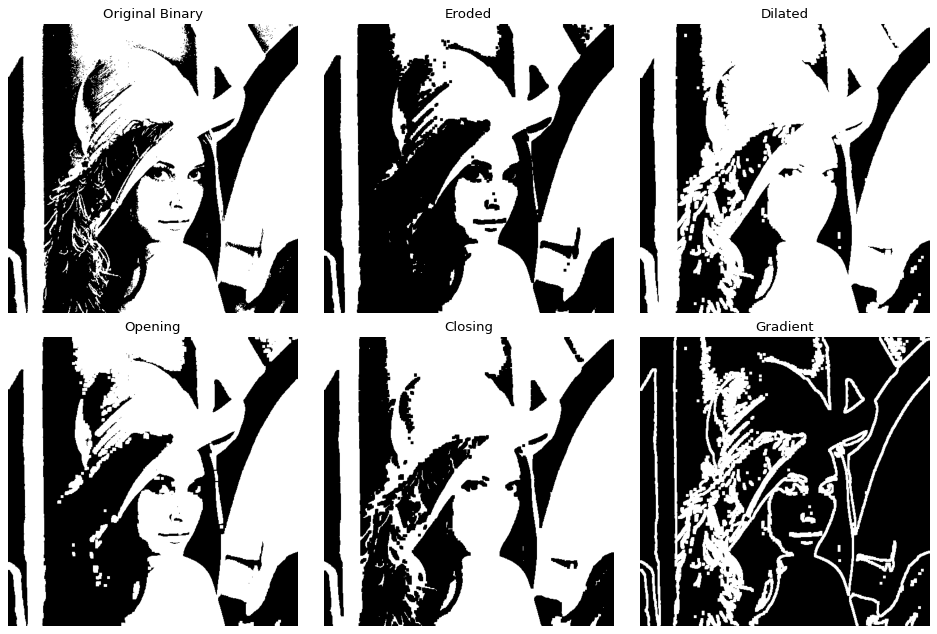

In [ ]:
binary = thresh_otsu

# 5×5 square structuring element. For a circle or cross shape: cv2.getStructuringElement().
kernel = np.ones((5, 5), np.uint8)

eroded   = cv2.erode(binary, kernel, iterations=1)
dilated  = cv2.dilate(binary, kernel, iterations=1)
opened   = cv2.morphologyEx(binary, cv2.MORPH_OPEN,     kernel)
closed   = cv2.morphologyEx(binary, cv2.MORPH_CLOSE,    kernel)
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(binary,   cmap='gray'); axes[0, 0].set_title('Original Binary')
axes[0, 1].imshow(eroded,   cmap='gray'); axes[0, 1].set_title('Eroded')
axes[0, 2].imshow(dilated,  cmap='gray'); axes[0, 2].set_title('Dilated')
axes[1, 0].imshow(opened,   cmap='gray'); axes[1, 0].set_title('Opening')
axes[1, 1].imshow(closed,   cmap='gray'); axes[1, 1].set_title('Closing')
axes[1, 2].imshow(gradient, cmap='gray'); axes[1, 2].set_title('Gradient')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()


## Contour Detection

Contour detection goes beyond marking edge pixels: it groups connected boundary pixels into complete outlines. In other words, **edge detection** answers “where are strong intensity changes?”, while **contour detection** answers “which of those boundaries form a shape?”. In practice, contours are usually extracted from a **binary image or edge map** and are useful when we want to measure or describe objects, for example with area, perimeter, or bounding boxes.

Found 396 contours


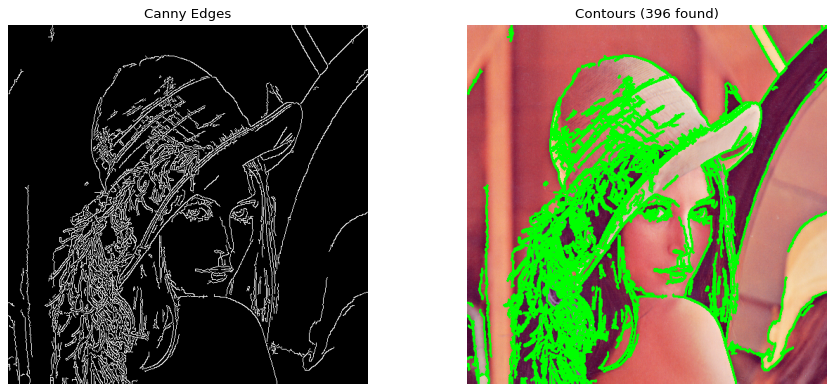

In [ ]:
# Find contours
contours, hierarchy = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on original image
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

print(f"Found {len(contours)} contours")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(canny, cmap='gray')
axes[0].set_title('Canny Edges')
axes[1].imshow(img_contours)
axes[1].set_title(f'Contours ({len(contours)} found)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Histogram Equalization

A **histogram** shows how pixel brightness is distributed in an image. When most pixels are packed into a narrow range, the image looks flat because too little of the available black-to-white scale is being used.

Histogram equalization is a practical contrast-recovery tool:

- use it when a grayscale image looks washed out or foggy
- use it when details are hard to distinguish because everything sits in mid-grey tones
- avoid it when brightness is already well balanced, because it can make the image look harsh

Two common choices are shown here:

| Method | Best for | Main limitation |
|--------|----------|-----------------|
| **Global equalization** | images whose low contrast is similar everywhere | can over-brighten some regions and flatten others |
| **CLAHE** | images with uneven lighting or mixed dark/bright areas | if pushed too hard, it can amplify noise |

In practice, **CLAHE** is often the better default because it improves local detail instead of applying one global correction to the whole image. The `clipLimit` parameter keeps the enhancement from becoming too aggressive, especially in smooth regions where noise would otherwise stand out.

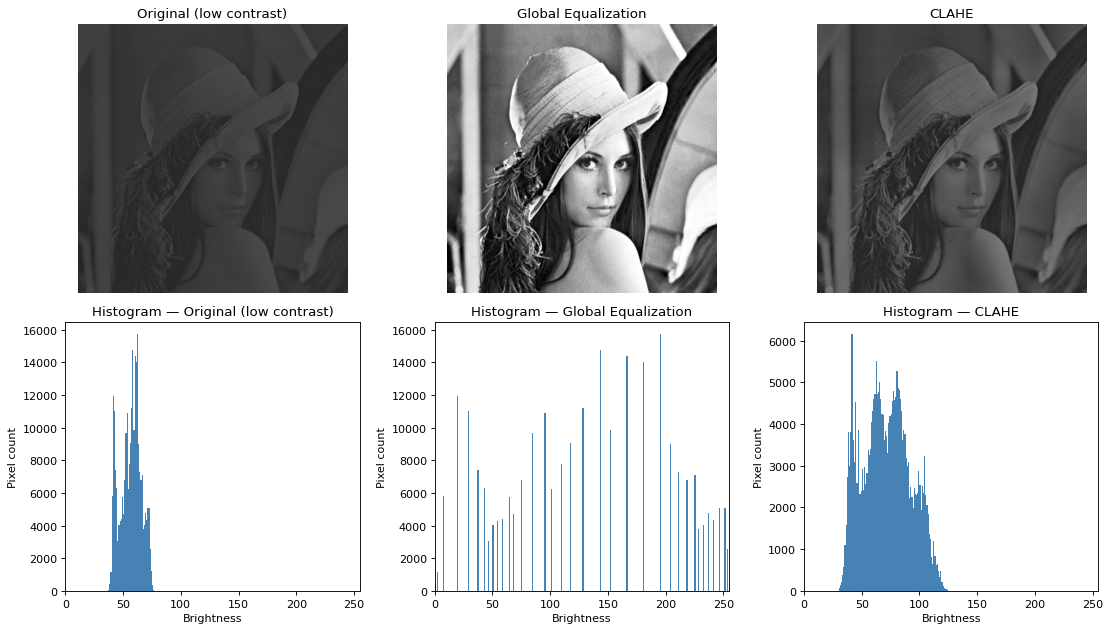

In [ ]:
gray = cv2.imread('../resources/images/lenna.png', cv2.IMREAD_GRAYSCALE)

# Compress the brightness range to simulate a low-contrast (foggy) image.
foggy_image = (gray * 0.2 + 30).astype(np.uint8)

global_eq = cv2.equalizeHist(foggy_image)

# clipLimit=2.0: max amplification per tile; tileGridSize=(8,8): image divided into 64 tiles.
clahe_tool = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_res = clahe_tool.apply(foggy_image)

images = [foggy_image, global_eq, clahe_res]
titles = ['Original (low contrast)', 'Global Equalization', 'CLAHE']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (img, title) in enumerate(zip(images, titles)):
    # Top row: images
    axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis('off')

    # Bottom row: histograms — show how brightness is spread across 0–255.
    axes[1, col].hist(img.ravel(), bins=256, range=(0, 256), color='steelblue', edgecolor='none')
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel('Brightness')
    axes[1, col].set_ylabel('Pixel count')
    axes[1, col].set_title(f'Histogram — {title}')

plt.tight_layout()
plt.show()

## Summary

| Operation | Function | Use Case |
|-----------|----------|----------|
| Gaussian Blur | `cv2.GaussianBlur()` | Noise reduction |
| Median Blur | `cv2.medianBlur()` | Salt-pepper noise |
| Bilateral | `cv2.bilateralFilter()` | Edge-preserving smoothing |
| Sobel | `cv2.Sobel()` | Edge detection (directional) |
| Canny | `cv2.Canny()` | Edge detection (best overall) |
| Threshold | `cv2.threshold()` | Binarization |
| Otsu | `cv2.THRESH_OTSU` | Automatic threshold |
| Erosion | `cv2.erode()` | Shrink white regions |
| Dilation | `cv2.dilate()` | Grow white regions |
| Contours | `cv2.findContours()` | Shape detection |

Next: [opencv_video.ipynb](opencv_video.ipynb) — the same operations applied frame by frame to video.